loading dataframe from drive

In [ ]:
import pandas as pd
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1k26vJfnpQx-Vl509-pjxhBkWu5efS12s')

loading models from drive

In [ ]:
import joblib
import gdown

#color - models were the features were colors alone
#mag - models where the features are the magnitudes alone

kkn = joblib.load(gdown.download('https://drive.google.com/uc?id=1q1suJ5P5Nvaq6F-1rgyBrdq_ZXAzexQS', quiet=True)) #both colors and magnitudes as features
kkn_color = joblib.load(gdown.download('https://drive.google.com/uc?id=1HfNczttXnvZbJm5jpSV4aYjPgAZI5t3K', quiet=True))
kkn_mag = joblib.load(gdown.download('https://drive.google.com/uc?id=1-XvGwAqDLyyQq0cVZ82ojJkAFMvemgL5', quiet=True))

rf = joblib.load(gdown.download('https://drive.google.com/uc?id=1NPVKcJnW0ixvH9FrDIW4nBsG5FcNjrGC', quiet=True))
rf_color = joblib.load(gdown.download('https://drive.google.com/uc?id=1-_bfCJY99VXMwN_kqHU31NBZCJYbNfAe', quiet=True))
rf_mag = joblib.load(gdown.download('https://drive.google.com/uc?id=19ILtsWIcm6zIl-gBFn9m1QVCvWXPZnld', quiet=True))

xgb = joblib.load(gdown.download('https://drive.google.com/uc?id=1rnCefqNNz6JZE8UxZMBchrbYpH5bOng5', quiet=True))
xgb_color = joblib.load(gdown.download('https://drive.google.com/uc?id=1FYIZ4FA6O2yVftmGOfXUKkm4S31YqrzZ', quiet=True))
xgb_mag = joblib.load(gdown.download('https://drive.google.com/uc?id=1_WK6tPnNa14SfPiJ2XLgN5M_Fh4Qaugp', quiet=True))

mlp = joblib.load(gdown.download('https://drive.google.com/uc?id=1-WnCW70-zddTvyhd6VHfHmIHhF-1jrsT', quiet=True))
mlp_color = joblib.load(gdown.download('https://drive.google.com/uc?id=1OXqhQyXfkf0vbSz7SYhhxZgU_lYxEUE8', quiet=True))
mlp_mag = joblib.load(gdown.download('https://drive.google.com/uc?id=1DyxkcJKEnb67F0Mm-U36vjHjNtFJ7p3c', quiet=True))

scaler = joblib.load(gdown.download('https://drive.google.com/uc?id=13rWRlzDbDFdEl28f3upgYkxP3shNrXYQ', quiet=True))



/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsRegressor from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.7.2 when using version 1.6.1. This might lead t

##setup

all things we did before so no need for commentary

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

feature_cols = ['u', 'g', 'r', 'i', 'z', 'u_g', 'g_r', 'r_i', 'i_z']
X = df[feature_cols].values
y = df['redshift'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    dz = (y_pred - y_true) / (1 + y_true)
    bias = np.mean(dz)
    sigma_nmad = 1.48 * np.median(np.abs(dz))
    outlier_fraction = np.mean(np.abs(dz) > 0.15)

    print(f"\n--- {model_name} ---")
    print(f"MAE:              {mae:.4f}")
    print(f"MSE:              {mse:.4f}")
    print(f"Bias:             {bias:.4f}")
    print(f"σ_NMAD:           {sigma_nmad:.4f}")
    print(f"Outlier fraction: {outlier_fraction:.4%}")

    return {'model': model_name, 'MAE': mae, 'MSE': mse,
            'bias': bias, 'sigma_NMAD': sigma_nmad,
            'outlier_fraction': outlier_fraction}

linear regression

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

get benchmarks

In [ ]:
y_pred_knn = kkn.predict(X_test_scaled)
y_pred_rf  = rf.predict(X_test_scaled)
y_pred_xgb = xgb.predict(X_test_scaled)
y_pred_mlp = mlp.predict(X_test_scaled)

results_lr = evaluate(y_test, y_pred_lr, "LR")
results_knn = evaluate(y_test, y_pred_knn, "kNN")
results_rf  = evaluate(y_test, y_pred_rf,  "RF")
results_xgb = evaluate(y_test, y_pred_xgb, "XGBoost")
results_mlp = evaluate(y_test, y_pred_mlp, "MLP")


--- LR ---
MAE:              0.0712
MSE:              0.0118
Bias:             0.0054
σ_NMAD:           0.0499
Outlier fraction: 5.3367%

--- kNN ---
MAE:              0.0477
MSE:              0.0075
Bias:             0.0027
σ_NMAD:           0.0274
Outlier fraction: 2.9086%

--- RF ---
MAE:              0.0460
MSE:              0.0071
Bias:             0.0023
σ_NMAD:           0.0259
Outlier fraction: 2.8387%

--- XGBoost ---
MAE:              0.0462
MSE:              0.0072
Bias:             0.0024
σ_NMAD:           0.0264
Outlier fraction: 2.8125%

--- MLP ---
MAE:              0.0472
MSE:              0.0073
Bias:             0.0036
σ_NMAD:           0.0275
Outlier fraction: 2.7950%




---


#quick comparison

will be discussed furthur in the report

In [ ]:
summary = pd.DataFrame([results_lr, results_knn, results_rf, results_xgb, results_mlp])
summary = summary.set_index('model').round(4)
summary['outlier_fraction'] = (summary['outlier_fraction'] * 100).round(2).astype(str) + '%'
summary.columns = ['MAE', 'MSE', 'Bias', 'σ_NMAD', 'Outlier %']
summary

,MAE,MSE,Bias,σ_NMAD,Outlier %
model,,,,,
LR,0.0712,0.0118,0.0054,0.0499,5.34%
kNN,0.0477,0.0075,0.0027,0.0274,2.91%
RF,0.0460,0.0071,0.0023,0.0259,2.84%
XGBoost,0.0462,0.0072,0.0024,0.0264,2.81%
MLP,0.0472,0.0073,0.0036,0.0275,2.8%


comparing our models, seems like RF is a winner, by a close margin

In [ ]:
pd.DataFrame({
    'Baseline ': [0.0118, 0.0080, 0.0076, 0.0078, 0.0078],
    'Tuned':    [results_lr['MSE'], results_knn['MSE'], results_rf['MSE'],
                        results_xgb['MSE'], results_mlp['MSE']],
    'Henghes':         [0.0057, 0.0044, 0.0042, 0.0043, 0.0047],
}, index=['LR', 'kNN', 'RF', 'XGBoost\BDT', 'MLP']).round(4)

<>:6: SyntaxWarning: invalid escape sequence '\B'
<>:6: SyntaxWarning: invalid escape sequence '\B'
/tmp/ipykernel_5843/3618095551.py:6: SyntaxWarning: invalid escape sequence '\B'
  }, index=['LR', 'kNN', 'RF', 'XGBoost\BDT', 'MLP']).round(4)


,Baseline,Tuned,Henghes
LR,0.0118,0.0118,0.0057
kNN,0.0080,0.0075,0.0044
RF,0.0076,0.0071,0.0042
XGBoost\BDT,0.0078,0.0072,0.0043
MLP,0.0078,0.0073,0.0047


##predicted vs true

we stil preformed worse in MSE than henghes after tuning. intersting talking point for report


##predicted vs true

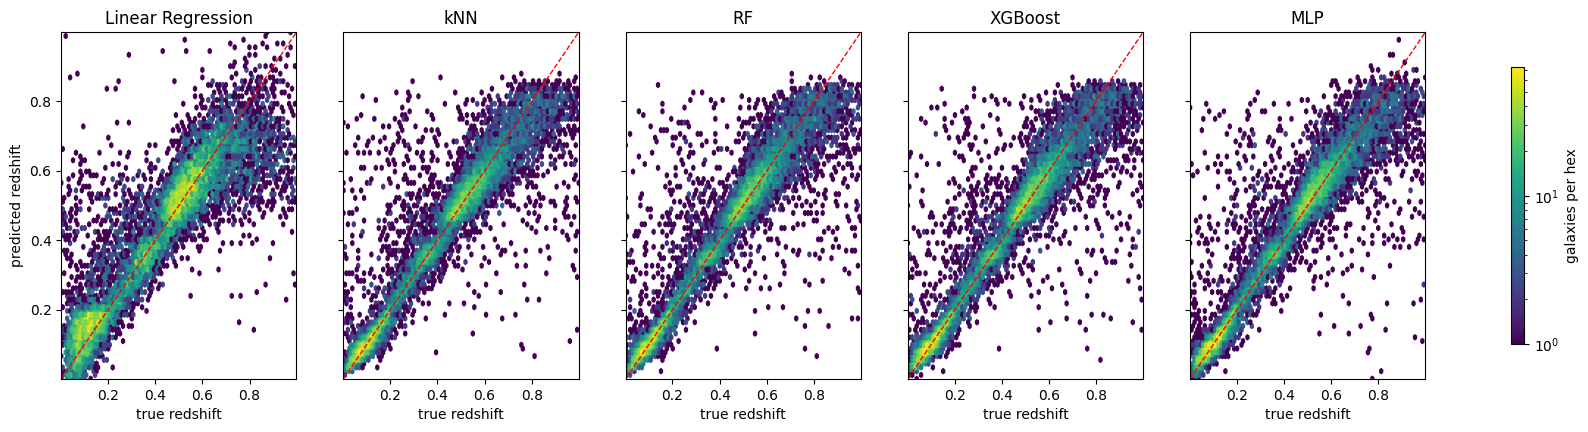

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

preds = {
    'Linear Regression': y_pred_lr,
    'kNN': y_pred_knn,
    'RF': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'MLP': y_pred_mlp,
}

fig, axes = plt.subplots(1, 5, figsize=(22, 4.5), sharex=True, sharey=True)

# shared axis limits so plots are comparable
lim = [y_test.min(), y_test.max()]

for ax, (name, y_pred) in zip(axes, preds.items()):
    hb = ax.hexbin(y_test, y_pred, gridsize=80, cmap='viridis',
                   norm=LogNorm(), mincnt=1, extent=(*lim, *lim))
    ax.plot(lim, lim, 'r--', lw=1)  # y=x reference
    ax.set_xlabel('true redshift')
    ax.set_title(name)
    ax.set_xlim(lim)
    ax.set_ylim(lim)

axes[0].set_ylabel('predicted redshift')
fig.colorbar(hb, ax=axes, label='galaxies per hex', shrink=0.8)
plt.show()

our models (exluding LR) preform very simalairly. ref papers found the same thing, will be discussed later

##Residuals vs true redshift

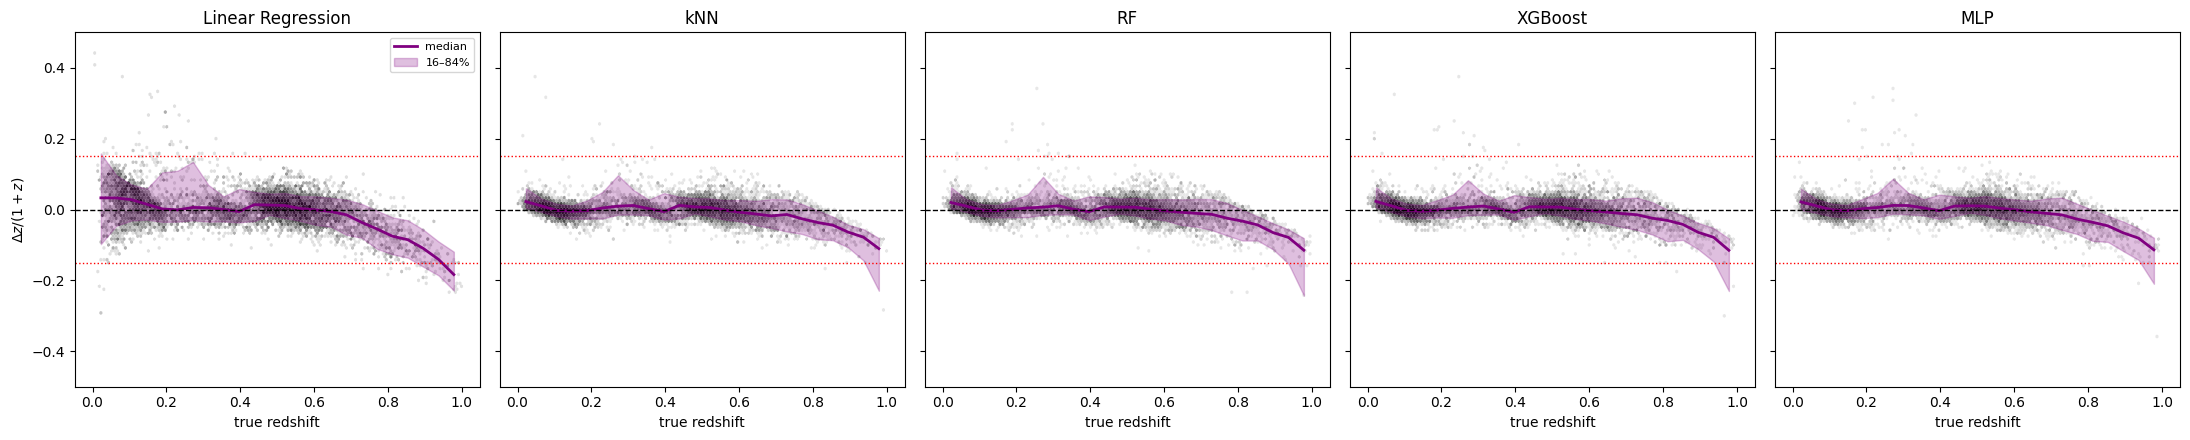

In [ ]:
from scipy.stats import binned_statistic

fig, axes = plt.subplots(1, 5, figsize=(22, 4.5), sharex=True, sharey=True)

# bin edges across the redshift range
bins = np.linspace(y_test.min(), y_test.max(), 25)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

for ax, (name, y_pred) in zip(axes, preds.items()):
    dz = (y_pred - y_test) / (1 + y_test)

    # background density (replaces the slow scatter)
    ax.hexbin(y_test, dz,
              gridsize=(120, 60),
              extent=(y_test.min(), y_test.max(), -0.5, 0.5),
              cmap='Greys', mincnt=1, bins='log',
              linewidths=0)

    # binned stats (vectorized)
    med, _, _    = binned_statistic(y_test, dz, statistic='median', bins=bins)
    lo,  _, _    = binned_statistic(y_test, dz, statistic=lambda x: np.percentile(x, 16), bins=bins)
    hi,  _, _    = binned_statistic(y_test, dz, statistic=lambda x: np.percentile(x, 84), bins=bins)
    counts, _, _ = binned_statistic(y_test, dz, statistic='count', bins=bins)

    sparse = counts <= 10
    med[sparse] = np.nan
    lo[sparse]  = np.nan
    hi[sparse]  = np.nan

    ax.plot(bin_centers, med, color='purple', lw=2, label='median')
    ax.fill_between(bin_centers, lo, hi, color='purple', alpha=0.25, label='16–84%')

    # reference lines
    ax.axhline(0, color='k', ls='--', lw=1)
    ax.axhline(0.15, color='r', ls=':', lw=1)
    ax.axhline(-0.15, color='r', ls=':', lw=1)

    ax.set_xlabel('true redshift')
    ax.set_title(name)
    ax.set_ylim(-0.5, 0.5)

axes[0].set_ylabel(r'$\Delta z / (1+z)$')
axes[0].legend(loc='upper right', fontsize=8)



plt.tight_layout()

##feature importance (RF, xgb)

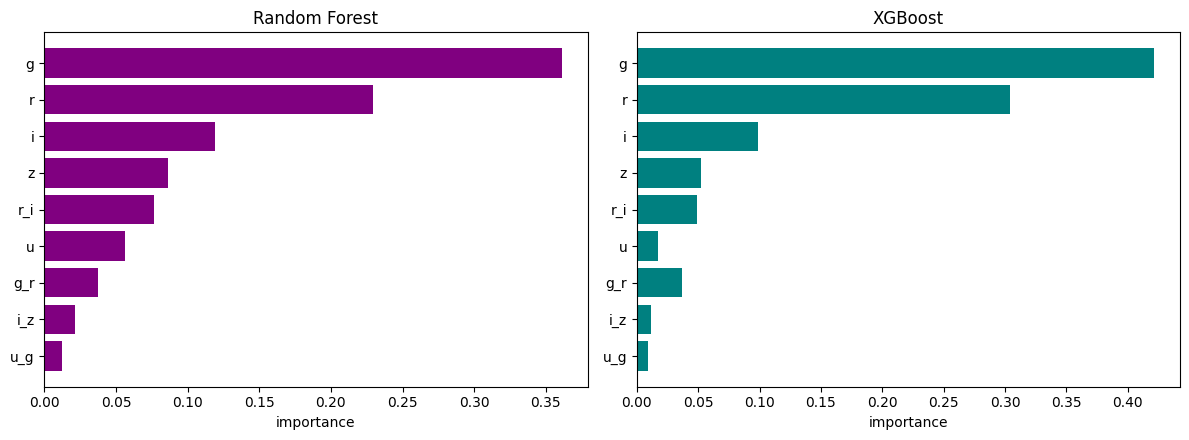

In [ ]:
rf_imp  = rf.feature_importances_
xgb_imp = xgb.feature_importances_

# sort by RF importance for consistent ordering
order = np.argsort(rf_imp)[::-1]
features_sorted = [feature_cols[i] for i in order]
rf_sorted  = rf_imp[order]
xgb_sorted = xgb_imp[order]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].barh(features_sorted, rf_sorted, color='purple')
axes[0].set_title('Random Forest')
axes[0].set_xlabel('importance')
axes[0].invert_yaxis()

axes[1].barh(features_sorted, xgb_sorted, color='teal')
axes[1].set_title('XGBoost')
axes[1].set_xlabel('importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


#abaltion (magnitudes vs color vs both)

In [ ]:
mag_cols   = ['u', 'g', 'r', 'i', 'z']
color_cols = ['u_g', 'g_r', 'r_i', 'i_z']

X_mag   = df[mag_cols].values
X_color = df[color_cols].values

# same random_state=42 so splits align with the 9-feature test set
X_train_m, X_test_m, _, _ = train_test_split(X_mag,   y, test_size=0.2, random_state=42)
X_train_c, X_test_c, _, _ = train_test_split(X_color, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler_m = StandardScaler().fit(X_train_m)
scaler_c = StandardScaler().fit(X_train_c)

X_test_m_scaled = scaler_m.transform(X_test_m)
X_test_c_scaled = scaler_c.transform(X_test_c)

In [ ]:
#linear models
lr_mag   = LinearRegression().fit(scaler_m.transform(X_train_m), y_train)
lr_color = LinearRegression().fit(scaler_c.transform(X_train_c), y_train)

y_pred_lr_mag   = lr_mag.predict(X_test_m_scaled)
y_pred_lr_color = lr_color.predict(X_test_c_scaled)

In [ ]:
# mag-only predictions
y_pred_knn_mag = kkn_mag.predict(X_test_m_scaled)
y_pred_rf_mag  = rf_mag.predict(X_test_m_scaled)
y_pred_xgb_mag = xgb_mag.predict(X_test_m_scaled)
y_pred_mlp_mag = mlp_mag.predict(X_test_m_scaled)

# color-only predictions
y_pred_knn_color = kkn_color.predict(X_test_c_scaled)
y_pred_rf_color  = rf_color.predict(X_test_c_scaled)
y_pred_xgb_color = xgb_color.predict(X_test_c_scaled)
y_pred_mlp_color = mlp_color.predict(X_test_c_scaled)

In [ ]:
# mag-only
results_lr_mag   = evaluate(y_test, y_pred_lr_mag,   "LR (mags)")
results_knn_mag  = evaluate(y_test, y_pred_knn_mag,  "kNN (mags)")
results_rf_mag   = evaluate(y_test, y_pred_rf_mag,   "RF (mags)")
results_xgb_mag  = evaluate(y_test, y_pred_xgb_mag,  "XGBoost (mags)")
results_mlp_mag  = evaluate(y_test, y_pred_mlp_mag,  "MLP (mags)")

# color-only
results_lr_color  = evaluate(y_test, y_pred_lr_color,  "LR (colors)")
results_knn_color = evaluate(y_test, y_pred_knn_color, "kNN (colors)")
results_rf_color  = evaluate(y_test, y_pred_rf_color,  "RF (colors)")
results_xgb_color = evaluate(y_test, y_pred_xgb_color, "XGBoost (colors)")
results_mlp_color = evaluate(y_test, y_pred_mlp_color, "MLP (colors)")


--- LR (mags) ---
MAE:              0.0712
MSE:              0.0118
Bias:             0.0054
σ_NMAD:           0.0499
Outlier fraction: 5.3367%

--- kNN (mags) ---
MAE:              0.0515
MSE:              0.0080
Bias:             0.0029
σ_NMAD:           0.0317
Outlier fraction: 3.0658%

--- RF (mags) ---
MAE:              0.0477
MSE:              0.0073
Bias:             0.0024
σ_NMAD:           0.0280
Outlier fraction: 2.7950%

--- XGBoost (mags) ---
MAE:              0.0482
MSE:              0.0074
Bias:             0.0027
σ_NMAD:           0.0289
Outlier fraction: 2.8474%

--- MLP (mags) ---
MAE:              0.0472
MSE:              0.0073
Bias:             0.0062
σ_NMAD:           0.0281
Outlier fraction: 2.8474%

--- LR (colors) ---
MAE:              0.1171
MSE:              0.0298
Bias:             0.0151
σ_NMAD:           0.0905
Outlier fraction: 17.7133%

--- kNN (colors) ---
MAE:              0.0515
MSE:              0.0095
Bias:             0.0016
σ_NMAD:           0.028

In [ ]:
# collect all results into one big dataframe
all_results = [
    # LR
    {**results_lr_mag,   'feature_set': 'Mag'},
    {**results_lr_color, 'feature_set': 'Color'},
    {**results_lr,       'feature_set': 'Both'},
    # kNN
    {**results_knn_mag,   'feature_set': 'Mag'},
    {**results_knn_color, 'feature_set': 'Color'},
    {**results_knn,       'feature_set': 'Both'},
    # RF
    {**results_rf_mag,   'feature_set': 'Mag'},
    {**results_rf_color, 'feature_set': 'Color'},
    {**results_rf,       'feature_set': 'Both'},
    # XGBoost
    {**results_xgb_mag,   'feature_set': 'Mag'},
    {**results_xgb_color, 'feature_set': 'Color'},
    {**results_xgb,       'feature_set': 'Both'},
    # MLP
    {**results_mlp_mag,   'feature_set': 'Mag'},
    {**results_mlp_color, 'feature_set': 'Color'},
    {**results_mlp,       'feature_set': 'Both'},
]

full_table = pd.DataFrame(all_results)

full_table['model'] = full_table['model'].str.replace(r'\s*\(.*\)', '', regex=True)

full_table = full_table[['model', 'feature_set', 'MAE', 'MSE', 'bias', 'sigma_NMAD', 'outlier_fraction']]
full_table['outlier_fraction'] = (full_table['outlier_fraction'] * 100).round(2).astype(str) + '%'
full_table[['MAE', 'MSE', 'bias', 'sigma_NMAD']] = full_table[['MAE', 'MSE', 'bias', 'sigma_NMAD']].round(4)
full_table.columns = ['Model', 'Features', 'MAE', 'MSE', 'Bias', 'σ_NMAD', 'Outlier %']

full_table.set_index(['Model', 'Features'])

MAE     MSE    Bias  σ_NMAD Outlier %
Model   Features                                          
LR      Mag       0.0712  0.0118  0.0054  0.0499     5.34%
        Color     0.1171  0.0298  0.0151  0.0905    17.71%
        Both      0.0712  0.0118  0.0054  0.0499     5.34%
kNN     Mag       0.0515  0.0080  0.0029  0.0317     3.07%
        Color     0.0515  0.0095  0.0016  0.0280     3.65%
        Both      0.0477  0.0075  0.0027  0.0274     2.91%
RF      Mag       0.0477  0.0073  0.0024  0.0280      2.8%
        Color     0.0515  0.0093  0.0041  0.0279     3.76%
        Both      0.0460  0.0071  0.0023  0.0259     2.84%
XGBoost Mag       0.0482  0.0074  0.0027  0.0289     2.85%
        Color     0.0530  0.0096  0.0040  0.0294     3.88%
        Both      0.0462  0.0072  0.0024  0.0264     2.81%
MLP     Mag       0.0472  0.0073  0.0062  0.0281     2.85%
        Color     0.0536  0.0094  0.0113  0.0311     3.95%
        Both      0.0472  0.0073  0.0036  0.0275      2.8%

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

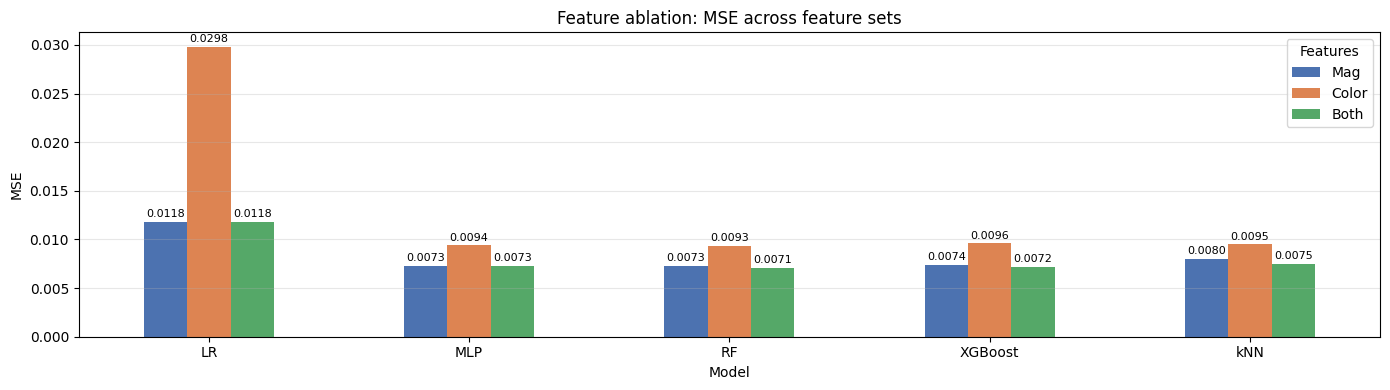

In [ ]:
pivot = full_table.reset_index().pivot(
    index='Model', columns='Features', values='MSE'
)[['Mag', 'Color', 'Both']]

ax = pivot.plot(
    kind='bar', figsize=(14, 4),
    color=['#4c72b0', '#dd8452', '#55a868']
)

ax.set_ylabel('MSE')
ax.set_title('Feature ablation: MSE across feature sets')
ax.set_xticklabels(pivot.index, rotation=0)
ax.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=8, padding=2)

plt.tight_layout()

plt.show()